In [1]:
!pip install polars -q

In [3]:
import gzip
import shutil

# Unzip the file you uploaded
with gzip.open("2025-06-05-14.json.gz", "rb") as f_in:
    with open("gharchive.json", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("✅ File unzipped successfully!")

✅ File unzipped successfully!


In [4]:
import json

# Read just first 3 lines to see what 1 event looks like
with open("gharchive.json") as f:
    for i, line in enumerate(f):
        event = json.loads(line)
        print(json.dumps(event, indent=2))
        print("---")
        if i == 2:   # stop after 3 events
            break

{
  "id": "50559167367",
  "type": "PushEvent",
  "actor": {
    "id": 97797596,
    "login": "DhanushkaNP",
    "display_login": "DhanushkaNP",
    "gravatar_id": "",
    "url": "https://api.github.com/users/DhanushkaNP",
    "avatar_url": "https://avatars.githubusercontent.com/u/97797596?"
  },
  "repo": {
    "id": 981555789,
    "name": "DhanushkaNP/lawggle-profile-setting",
    "url": "https://api.github.com/repos/DhanushkaNP/lawggle-profile-setting"
  },
  "payload": {
    "repository_id": 981555789,
    "push_id": 24722633194,
    "size": 1,
    "distinct_size": 1,
    "ref": "refs/heads/main",
    "head": "07d677aed63b95351ec9a1f905ef7733abdea881",
    "before": "b5bd1c3b96e26f08fe6a71506b2010af53233062",
    "commits": [
      {
        "sha": "07d677aed63b95351ec9a1f905ef7733abdea881",
        "author": {
          "email": "97797596+DhanushkaNP@users.noreply.github.com",
          "name": "Dhanushka Nuwan Premasiri"
        },
        "message": "fix",
        "distinct": tr

In [5]:
import polars as pl
import json

rows = []   # empty list to collect all events

with open("gharchive.json") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue   # skip empty lines

        event = json.loads(line)   # convert text to dictionary

        # Pick only the fields we need
        rows.append({
            "event_type" : event.get("type", ""),
            "actor"      : event.get("actor", {}).get("login", ""),
            "repo_name"  : event.get("repo",  {}).get("name",  ""),
            "created_at" : event.get("created_at", "")
        })

# Create Polars DataFrame (like an Excel table)
df = pl.DataFrame(rows)

print(f"✅ Total events loaded : {len(df)}")
print(f"✅ Columns             : {df.columns}")
print()
df.head(5)

✅ Total events loaded : 152997
✅ Columns             : ['event_type', 'actor', 'repo_name', 'created_at']



event_type,actor,repo_name,created_at
str,str,str,str
"""PushEvent""","""DhanushkaNP""","""DhanushkaNP/lawggle-profile-se…","""2025-06-05T14:00:04Z"""
"""PushEvent""","""matviiX-U2""","""matviiX-U2/3rd-devs""","""2025-06-05T14:00:04Z"""
"""ForkEvent""","""martin-helmich""","""WordPress/phpunit-test-runner""","""2025-06-05T14:00:04Z"""
"""PushEvent""","""la-tribu-pusher""","""Risk-DAO/simulation-results""","""2025-06-05T14:00:04Z"""
"""PushEvent""","""sakakiki""","""gafu2317/WireVR""","""2025-06-05T14:00:04Z"""


In [6]:
# How many unique repositories?
print("Unique Repos   :", df["repo_name"].n_unique())

# How many unique people did something?
print("Unique Users   :", df["actor"].n_unique())

# What types of events exist?
print("Event Types    :", df["event_type"].unique().to_list())

# How many of each event type?
event_summary = (
    df.group_by("event_type")
      .len()
      .sort("len", descending=True)
)
print(event_summary)

Unique Repos   : 70880
Unique Users   : 59718
Event Types    : ['PublicEvent', 'ReleaseEvent', 'PullRequestReviewEvent', 'WatchEvent', 'IssueCommentEvent', 'IssuesEvent', 'GollumEvent', 'CreateEvent', 'PullRequestReviewCommentEvent', 'ForkEvent', 'MemberEvent', 'PushEvent', 'PullRequestEvent', 'DeleteEvent', 'CommitCommentEvent']
shape: (15, 2)
┌────────────────────┬───────┐
│ event_type         ┆ len   │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ PushEvent          ┆ 84805 │
│ CreateEvent        ┆ 21295 │
│ PullRequestEvent   ┆ 13095 │
│ IssueCommentEvent  ┆ 8456  │
│ WatchEvent         ┆ 5386  │
│ …                  ┆ …     │
│ ReleaseEvent       ┆ 818   │
│ PublicEvent        ┆ 638   │
│ MemberEvent        ┆ 554   │
│ GollumEvent        ┆ 148   │
│ CommitCommentEvent ┆ 116   │
└────────────────────┴───────┘


In [7]:
import pandas as pd

# Group by repo and count different things
repo_counts = (
    df
    .group_by("repo_name")
    .agg([
        pl.len().alias("total_events"),

        pl.col("actor").n_unique().alias("unique_contributors"),

        (pl.col("event_type") == "WatchEvent").sum().alias("stars"),

        (pl.col("event_type") == "ForkEvent").sum().alias("forks"),

        (pl.col("event_type") == "PushEvent").sum().alias("pushes"),

        (pl.col("event_type") == "PullRequestEvent").sum().alias("pull_requests"),
    ])
    .sort("total_events", descending=True)
)

# Convert to Pandas for scoring and charts
repo_df = repo_counts.to_pandas()

print("✅ Top 10 Most Active Repos:")
repo_df.head(10)

✅ Top 10 Most Active Repos:


,repo_name,total_events,unique_contributors,stars,forks,pushes,pull_requests
0,zacw-243L/How-to-inflate-your-commits-,565,1,0,0,565,0
1,Bishan-Pankaja/test,340,1,0,0,340,0
2,xrwt/degisiklik-yapan-sistem,334,1,0,0,334,0
3,adi224foreverg/globaldl,303,1,0,0,303,0
4,valhallaguide/valhallabot,298,1,0,0,298,0
5,freefastconnect/fastconnect,287,1,0,0,287,0
6,canstralian/CyberAttackDetection-Python,279,2,0,0,0,0
7,TheDimPause/microblog.archive,256,1,0,0,256,0
8,nectariferous/TestFlight,250,1,0,0,250,0
9,Jayon28/picbed,248,1,0,0,248,0


In [8]:
import numpy as np

# Step 1: Normalize a column to 0-100 scale
# This makes all metrics comparable
def normalize(column):
    col = column.to_numpy(dtype=float)
    min_val = col.min()
    max_val = col.max()
    if max_val == min_val:
        return np.zeros_like(col)
    return (col - min_val) / (max_val - min_val) * 100

# Step 2: Normalize each metric
n_events       = normalize(repo_df["total_events"])
n_contributors = normalize(repo_df["unique_contributors"])
n_stars        = normalize(repo_df["stars"])
n_forks        = normalize(repo_df["forks"])

# Step 3: Combine into one score
# Weights must add up to 1.0
score = (
    0.40 * n_events        +    # 40% weight — total activity
    0.30 * n_contributors  +    # 30% weight — community size
    0.20 * n_stars         +    # 20% weight — popularity
    0.10 * n_forks              # 10% weight — usage interest
)

# Step 4: Add score column
repo_df["score"] = np.round(score, 2)

# Step 5: Sort by score
repo_df = repo_df.sort_values("score", ascending=False).reset_index(drop=True)
repo_df.index += 1   # rank starts from 1

print("✅ Top 10 Repos by Score:")
repo_df[["repo_name", "score", "total_events", "unique_contributors", "stars", "forks"]].head(10)

✅ Top 10 Repos by Score:


,repo_name,score,total_events,unique_contributors,stars,forks
1,google-gemini/gemini-fullstack-langgraph-quick...,60.89,70,65,61,6
2,IRS-Public/direct-file,41.46,46,44,40,5
3,zacw-243L/How-to-inflate-your-commits-,40.00,565,1,0,0
4,llvm/llvm-project,30.56,108,50,0,0
5,Bishan-Pankaja/test,24.04,340,1,0,0
6,xrwt/degisiklik-yapan-sistem,23.62,334,1,0,0
7,MetaMask/metamask-mobile,22.19,142,27,0,0
8,n8n-io/n8n,22.16,30,27,15,3
9,elastic/kibana,22.16,102,33,0,0
10,adi224foreverg/globaldl,21.42,303,1,0,0


/tmp/ipykernel_7099/3369925187.py:15: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7099/3369925187.py:16: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("top_repos.png")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


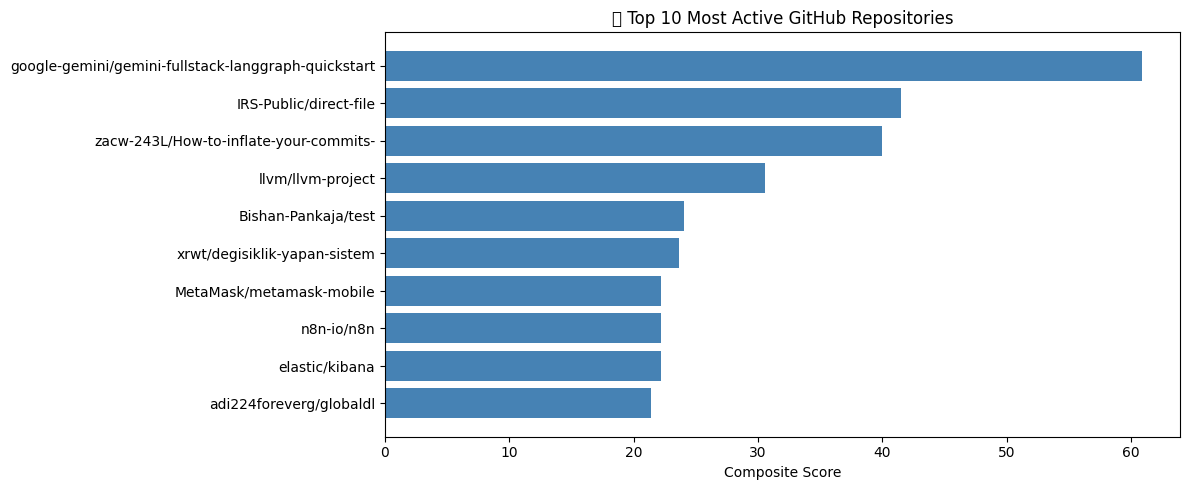

✅ Chart saved as top_repos.png


In [9]:
import matplotlib.pyplot as plt

top10 = repo_df.head(10)

plt.figure(figsize=(12, 5))

plt.barh(
    top10["repo_name"][::-1],    # repos on y-axis (reversed so #1 is on top)
    top10["score"][::-1],         # scores on x-axis
    color="steelblue"
)

plt.xlabel("Composite Score")
plt.title("🏆 Top 10 Most Active GitHub Repositories")
plt.tight_layout()
plt.savefig("top_repos.png")
plt.show()

print("✅ Chart saved as top_repos.png")

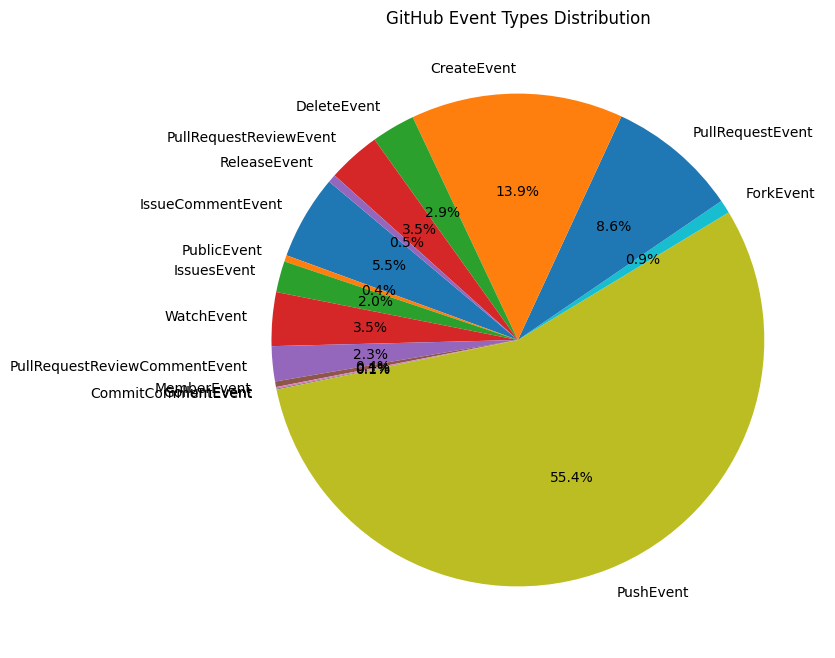

✅ Chart saved as event_types.png


In [10]:
event_counts = df.group_by("event_type").len().to_pandas()

plt.figure(figsize=(8, 8))

plt.pie(
    event_counts["len"],
    labels=event_counts["event_type"],
    autopct="%1.1f%%",        # show percentage on each slice
    startangle=140
)

plt.title("GitHub Event Types Distribution")
plt.savefig("event_types.png")
plt.show()

print("✅ Chart saved as event_types.png")

/tmp/ipykernel_7099/3973192362.py:14: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7099/3973192362.py:14: UserWarning: Glyph 127860 (\N{FORK AND KNIFE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7099/3973192362.py:15: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig("stars_vs_forks.png")
/tmp/ipykernel_7099/3973192362.py:15: UserWarning: Glyph 127860 (\N{FORK AND KNIFE}) missing from font(s) DejaVu Sans.
  plt.savefig("stars_vs_forks.png")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127860 (\N{FORK AND KNIFE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


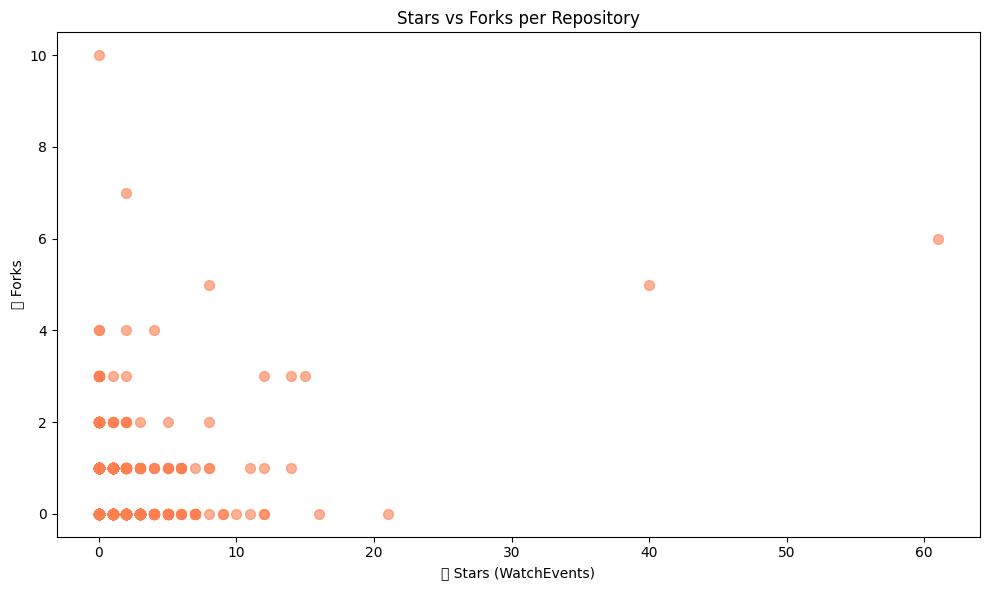

✅ Chart saved as stars_vs_forks.png


In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    repo_df["stars"],
    repo_df["forks"],
    alpha=0.6,          # transparency
    color="coral",
    s=50                # dot size
)

plt.xlabel("⭐ Stars (WatchEvents)")
plt.ylabel("🍴 Forks")
plt.title("Stars vs Forks per Repository")
plt.tight_layout()
plt.savefig("stars_vs_forks.png")
plt.show()

print("✅ Chart saved as stars_vs_forks.png")

In [12]:
repo_df.to_csv("repo_scores.csv", index=True)

print("✅ Saved repo_scores.csv")
print(f"   Total repos in file: {len(repo_df)}")

✅ Saved repo_scores.csv
   Total repos in file: 70880


## 📋 Project Conclusion

**Dataset:** GitHub Archive (gharchive.org) — 1 hour of real GitHub events

**Libraries Used:**
- Polars  → Fast data loading and aggregation
- Pandas  → Data analysis and CSV export
- NumPy   → Score normalization and calculation
- Matplotlib → Charts and visualizations

**What I did:**
1. Downloaded real GitHub event data from GH Archive
2. Loaded and explored the data using Polars
3. Counted activity per repository (events, stars, forks, PRs)
4. Normalized metrics using NumPy min-max normalization
5. Calculated a weighted composite score for each repo
6. Ranked top repositories by engagement score
7. Created 3 visualizations
8. Exported results to CSV

**Result:** Successfully identified the most active and community-engaged repositories.

In [13]:
import gzip
import shutil

# Unzip the file you uploaded
with gzip.open("2025-06-05-14.json.gz", "rb") as f_in:
    with open("gharchive.json", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("✅ Unzipped successfully!")

✅ Unzipped successfully!


In [14]:
import json
import os

input_file  = "gharchive.json"
output_file = "gharchive_small.json"

with open(input_file) as f_in, open(output_file, "w") as f_out:
    for i, line in enumerate(f_in):
        if i >= 5000:   # reduced to 5000 events
            break
        f_out.write(line)

size_mb = os.path.getsize(output_file) / (1024 * 1024)
print(f"✅ Done! File size: {size_mb:.2f} MB")

✅ Done! File size: 20.39 MB


In [15]:
from google.colab import files
files.download("gharchive_small.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>